In [1]:
import numpy as np
import scipy as sp
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 1
aw = 0.02
bw = 1
cw = 0.04
dw = 0
gw = 3.076278e-2
rw = 0.7071067
vol = 1000
w0 = 12.35
cUp = 0.0382

def infPotFunc(phi):
    x = np.exp(phi / np.sqrt(3))
    return float(w0**2 / vol**3 * (cUp / vol**(1/3) + aw / (x - bw) - cw / x + x**2 / vol * (dw - gw / (rw * x**3 / vol + 1))))

def infPotDerivFunc(phi):
    x = np.exp(phi / np.sqrt(3))
    return float(w0**2 / vol**3 * (-aw / (x - bw)**2 + cw / x**2 + 2 * x * (dw / vol - gw / (rw * x**3 + vol)) + 3 * gw * rw * x**4 / (rw * x**3 + vol)**2) * x / np.sqrt(3))

def infPotDeriv2Func(phi):
    x = np.exp(phi / np.sqrt(3))
    return infPotDerivFunc(phi) / np.sqrt(3) + \
        float(w0**2 / vol**3 * (2 * aw / (x - bw)**3 - 2 * cw / x**3 + 2 * (dw / vol - gw / (rw * x**3 + vol)) + 18 * gw * rw * x**3 / (rw * x**3 + vol)**2 - 18 * gw * rw * rw * x**6 / (rw * x**3 + vol)**3) * x**2 / 3)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

In [3]:
def slowrollEps(phi):
    return 0.5 * (infPotDerivFunc(phi) / infPotFunc(phi))**2

def slowrollEta(phi):
    return infPotDeriv2Func(phi) / infPotFunc(phi)

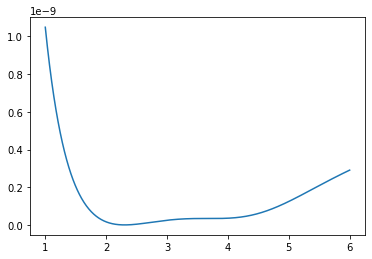

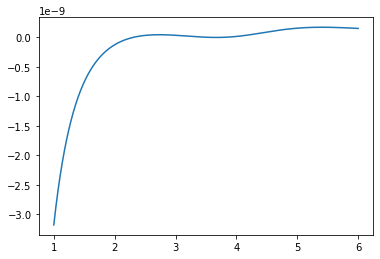

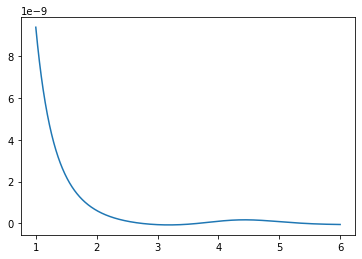

In [4]:
phis = np.linspace(1, 6, 1000)
vs = [infPotFunc(phi) for phi in phis]
vDers = [infPotDerivFunc(phi) for phi in phis]
vDer2s = [infPotDeriv2Func(phi) for phi in phis]

ax = plt.gca()
plt.plot(phis, vs)
plt.show()

ax = plt.gca()
plt.plot(phis, vDers)
plt.show()

ax = plt.gca()
plt.plot(phis, vDer2s)
plt.show()

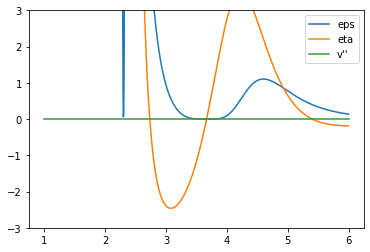

In [5]:
epss = [slowrollEps(phi) for phi in phis]
etas = [slowrollEta(phi) for phi in phis]

ax = plt.gca()
plt.plot(phis, epss, label="eps")
plt.plot(phis, etas, label="eta")
plt.plot(phis, vDer2s, label="v''")
ax.set_ylim(-3, 3)
plt.legend()
plt.show()

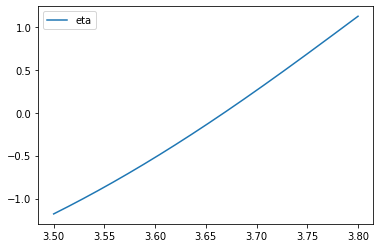

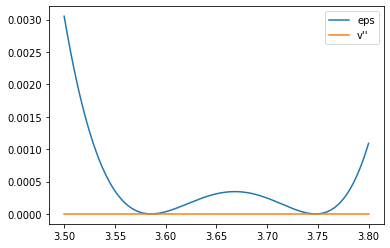

In [6]:
phisAroundInflec = np.linspace(3.5, 3.8, 1000)

epssAroundInfle = [slowrollEps(phi) for phi in phisAroundInflec]
etasAroundInfle = [slowrollEta(phi) for phi in phisAroundInflec]
vDer2sAroundInfle = [infPotDeriv2Func(phi) for phi in phisAroundInflec]

ax = plt.gca()
plt.plot(phisAroundInflec, etasAroundInfle, label="eta")
plt.legend()
plt.show()

ax = plt.gca()
plt.plot(phisAroundInflec, epssAroundInfle, label="eps")
plt.plot(phisAroundInflec, vDer2sAroundInfle, label="v''")
plt.legend()
plt.show()

In [7]:
# eta=±1の点として上下限を決める
upperBound = sp.optimize.bisect(lambda phi: slowrollEta(phi) - 1, 3.5, 3.8)
lowerBound = sp.optimize.bisect(lambda phi: slowrollEta(phi) + 1, 3.5, 3.8)
print(lowerBound, upperBound)

3.529369783189395 3.785924333345246


In [8]:
nGrid = 1000 
grids = np.linspace(lowerBound, upperBound, nGrid)

In [9]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0OriFunc"],
    ["Dirichlet"]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

In [10]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

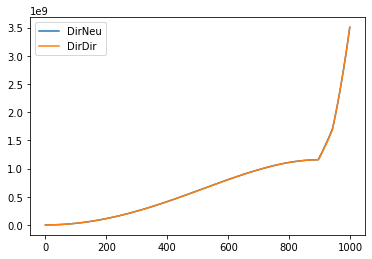

In [11]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

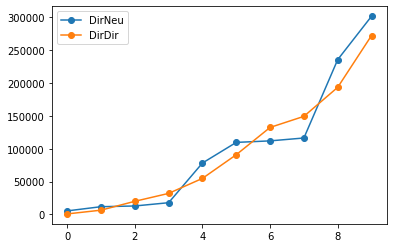

In [12]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [13]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[  5385.96251812  11774.04231472  12872.35371514  17849.89304759
  78274.09855078 109703.5884361  112015.21757441 116413.09998661
 235768.84892952 301824.54812307]
[   781.31409965   6474.20123509  19991.03748659  32029.82415355
  54878.16558805  90951.97966972 132483.35393323 149369.052346
 193576.77205435 272446.90465849]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

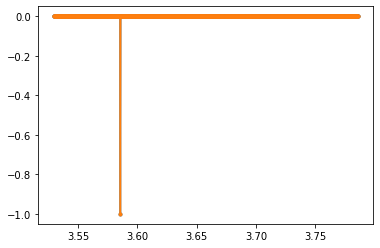

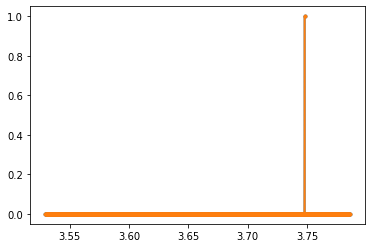

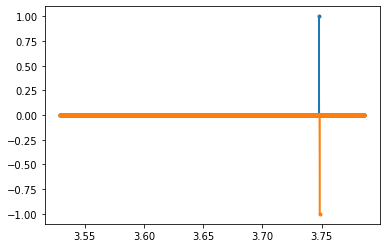

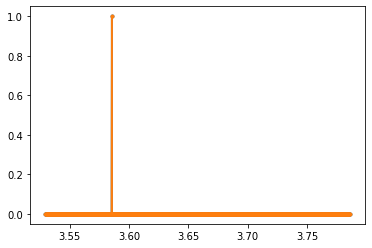

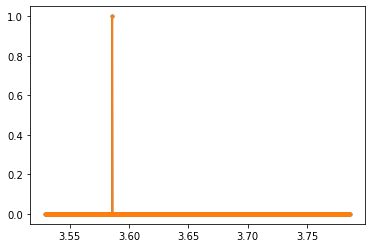

In [14]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

local minimum, maximumのあたりだけズーム

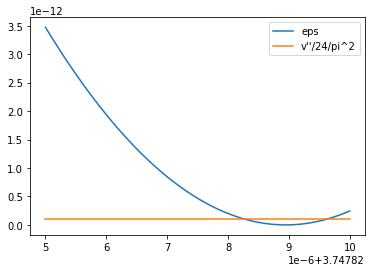

In [21]:
phisAroundInflec = np.linspace(3.747825, 3.74783, 1000)

epssAroundInfle = [slowrollEps(phi) for phi in phisAroundInflec]
vDer2sAroundInfle = [infPotDeriv2Func(phi) / 24 / np.pi**2  for phi in phisAroundInflec]

ax = plt.gca()
plt.plot(phisAroundInflec, epssAroundInfle, label="eps")
plt.plot(phisAroundInflec, vDer2sAroundInfle, label="v''/24/pi^2")
plt.legend()
plt.show()

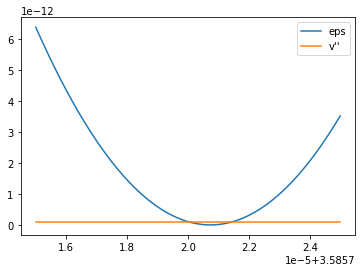

In [23]:
phisAroundInflec = np.linspace(3.585715, 3.585725, 1000)

epssAroundInfle = [slowrollEps(phi) for phi in phisAroundInflec]
vDer2sAroundInfle = [abs(infPotDeriv2Func(phi)) / 24 / np.pi**2 for phi in phisAroundInflec]

ax = plt.gca()
plt.plot(phisAroundInflec, epssAroundInfle, label="eps")
plt.plot(phisAroundInflec, vDer2sAroundInfle, label="v''")
plt.legend()
plt.show()

In [17]:
def etaCl(phi):
    v = infPotFunc(phi) / 24 / np.pi**2
    vDer = infPotDerivFunc(phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func(phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

ηcl=1の点を探索

In [18]:
from scipy.optimize import bisect

In [39]:
inflecLeftLB = bisect(lambda phi: etaCl(phi) - 0.01, 3.58571, 3.58572)
inflecLeftUB = bisect(lambda phi: etaCl(phi) - 0.01, 3.58572, 3.58573)
inflecRightLB = bisect(lambda phi: etaCl(phi) - 0.01, 3.74782, 3.747829)
inflecRightUB = bisect(lambda phi: etaCl(phi) - 0.01, 3.747829, 3.747840)
print(inflecLeftLB, inflecLeftUB, inflecRightLB, inflecRightUB)

3.5857158453261846 3.585725632203818 3.747824227778316 3.7478336698158983


ηcl>1の領域だけ細かくメッシュをとる

In [40]:
nGridPatch = 1000
customGrid = np.concatenate([np.linspace(lowerBound, inflecLeftLB, nGridPatch, endpoint=False),
                            np.linspace(inflecLeftLB, inflecLeftUB, nGridPatch, endpoint=False),
                            np.linspace(inflecLeftUB, inflecRightLB, nGridPatch, endpoint=False),
                            np.linspace(inflecRightLB, inflecRightUB, nGridPatch, endpoint=False),
                            np.linspace(inflecRightUB, upperBound, nGridPatch, endpoint=False)])
nCumtomGrid = len(customGrid)

In [41]:
fpFinDiff_DirNeu_customGrid = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nCumtomGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0OriFunc"],
    ["Dirichlet"],
    customGrid=[customGrid]
)

eigVals_DirNeu_customGrid, eigVecs_DirNeu_customGrid = np.linalg.eig(fpFinDiff_DirNeu_customGrid)
eigVecsSort_DirNeu_customGrid = eigVecs_DirNeu_customGrid.T[np.argsort(eigVals_DirNeu_customGrid)]
eigValsSort_DirNeu_customGrid = np.sort(eigVals_DirNeu_customGrid)

In [42]:
fpFinDiff_DirDir_customGrid = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nCumtomGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid]
)

eigVals_DirDir_customGrid, eigVecs_DirDir_customGrid = np.linalg.eig(fpFinDiff_DirDir_customGrid)
eigVecsSort_DirDir_customGrid = eigVecs_DirDir_customGrid.T[np.argsort(eigVals_DirDir_customGrid)]
eigValsSort_DirDir_customGrid = np.sort(eigVals_DirDir_customGrid)

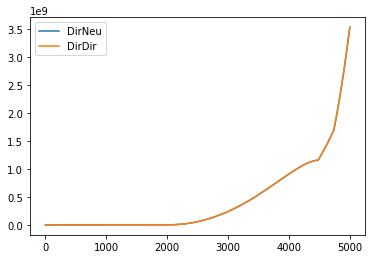

In [43]:
ax = plt.gca()
plt.plot(eigValsSort_DirNeu_customGrid, label = "DirNeu")
plt.plot(eigValsSort_DirDir_customGrid, label = "DirDir")
plt.legend()
plt.show()

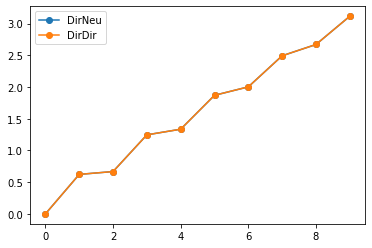

In [44]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_DirNeu_customGrid[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(10), eigValsSort_DirDir_customGrid[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [45]:
print(eigValsSort_DirNeu_customGrid[:10])
print(eigValsSort_DirDir_customGrid[:10])

[-4.17130184e-06  6.22953393e-01  6.67376953e-01  1.24589511e+00
  1.33474139e+00  1.86882124e+00  2.00208914e+00  2.49173180e+00
  2.66942021e+00  3.11462679e+00]
[-4.17130184e-06  6.22953393e-01  6.67376953e-01  1.24589511e+00
  1.33474139e+00  1.86882124e+00  2.00208914e+00  2.49173180e+00
  2.66942021e+00  3.11462679e+00]


最小固有値が負なのは良いのか...?

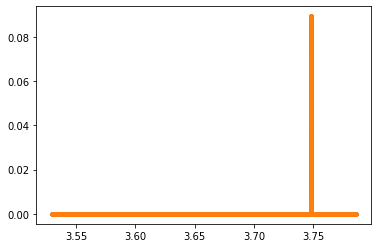

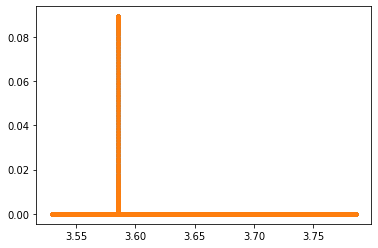

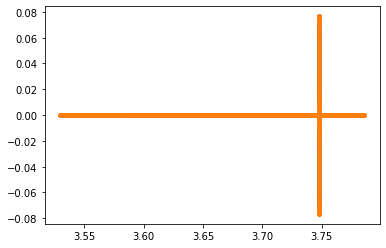

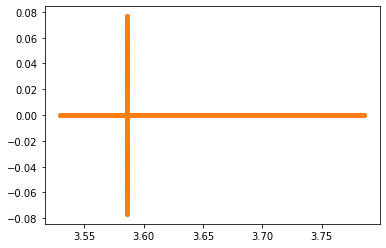

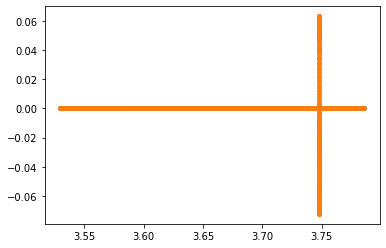

In [46]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
ax = plt.gca()

for iEig in range(5):
    plt.plot(customGrid[1:-1], eigVecsSort_DirNeu_customGrid[iEig],marker='.', label="DirNeu")
    plt.plot(customGrid[1:-1], eigVecsSort_DirDir_customGrid[iEig],marker='.', label="DirDir")
    plt.show()

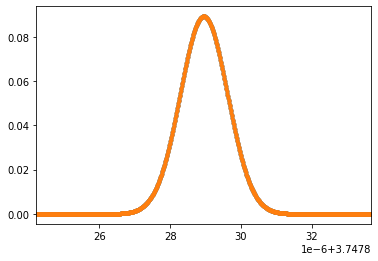

In [47]:
ax = plt.gca()
ax.set_xlim([inflecRightLB, inflecRightUB])
plt.plot(customGrid[1:-1], eigVecsSort_DirNeu_customGrid[0],marker='.', label="DirNeu")
plt.plot(customGrid[1:-1], eigVecsSort_DirDir_customGrid[0],marker='.', label="DirDir")

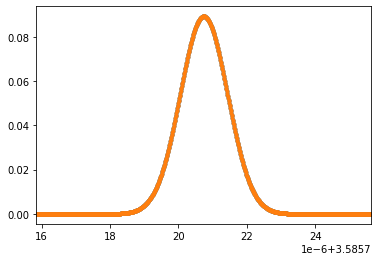

In [48]:
ax = plt.gca()
ax.set_xlim([inflecLeftLB, inflecLeftUB])
plt.plot(customGrid[1:-1], eigVecsSort_DirNeu_customGrid[1],marker='.', label="DirNeu")
plt.plot(customGrid[1:-1], eigVecsSort_DirDir_customGrid[1],marker='.', label="DirDir")